# Predictive Credit Risk Modeling

<b>Brief Objective</b>: \
This project develops a predictive decision engine to identify high-risk credit applicants using the German Credit Dataset. The goal of this Exploratory Data Analysis (EDA) is to uncover the key drivers of loan default and validate data integrity before proceeding to model training. By analyzing 1,000 historical loan records across 17 demographic and financial variables, we aim to establish a baseline for a classification model that prioritizes high recall to minimize financial exposure.

---

In [1]:
import os 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

# --- PATH SETUP --- 
current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, os.pardir))
data_dir = os.path.join(project_root, "data")
scripts_dir = os.path.join(project_root, "scripts")

data_path = os.path.join(data_dir, 'cleaned_german_credit.csv')

# Import CSV
df = pd.read_csv(data_path)
df.head(5)

,customer_id,age,sex,marital_status,job,employment_duration,housing,guarantors,num_dependants,checking_status,savings_status,amount,duration,purpose,credit_history,installment_rate,risk_label
0,1,67,male,single,skilled employee,> 7 years,own,none,1,< 0 DM,unknown/no savings,1169,6,radio/television,critical account/other credits existing (outsi...,4.0,0
1,2,22,female,non-single/single,skilled employee,1 - 4 years,own,none,1,0 - 200 DM,< 100 DM,5951,48,radio/television,existing credits paid back duly,2.0,1
2,3,49,male,single,unskilled employee,4 - 7 years,own,none,2,no account,< 100 DM,2096,12,education,critical account/other credits existing (outsi...,2.0,0
3,4,45,male,single,skilled employee,4 - 7 years,for free,gurantor,2,< 0 DM,< 100 DM,7882,42,furniture/equipment,existing credits paid back duly,2.0,0
4,5,53,male,single,skilled employee,1 - 4 years,for free,none,2,< 0 DM,< 100 DM,4870,24,car (new),delay paying off in the past,3.0,1


In [2]:
df['risk_label'].value_counts()

risk_label
0    700
1    300
Name: count, dtype: int64

In [3]:
print('-'*len('Check Data Types:'))
print('Check Data Types:')
print('-'*len('Check Data Types:'))
print(df.dtypes)
print('')
print('-'*len('Check For Missing Values:'))
print('Check For Missing Values:')
print('-'*len('Check For Missing Values:'))
print(df.isnull().sum())

-----------------
Check Data Types:
-----------------
customer_id              int64
age                      int64
sex                        str
marital_status             str
job                        str
employment_duration        str
housing                    str
guarantors                 str
num_dependants           int64
checking_status            str
savings_status             str
amount                   int64
duration                 int64
purpose                    str
credit_history             str
installment_rate       float64
risk_label               int64
dtype: object

-------------------------
Check For Missing Values:
-------------------------
customer_id            0
age                    0
sex                    0
marital_status         0
job                    0
employment_duration    0
housing                0
guarantors             0
num_dependants         0
checking_status        0
savings_status         0
amount                 0
duration               0
p

---

## Data Dictionary
There is a total of 17 columns: 
   - 7 numerical values (`int64` & `float64`)
   - 10 text values (`str`)
 
<u>Feature Variables</u>: 
   - <u>Quantitative Variables</u>: [`customer_id`, `age`, `num_dependants`, `amount`, `duration`, `installment_rate`]
   - <u>Qualitative Variables</u>: [`sex`, `job`, `employment_duration`, `housing`, `guarantors`, `checking_status`, `saving_status`, `purpose`, `credit_history`]

<u>Target Variable</b>: \
[`risk_label`]

<u>risk_label</u> \
[0 = 700] \
[1 = 300]


The initial data scan confirms a clean dataset of 1,000 entries with no missing values. The features consist of a mix of numerical financial data (amount, duration) and categorical demographic data (housing, job, marital status). Our target variable is risk_label, where '1' represents a default and '0' represents a successful repayment. Analysis of the target variable reveals a class imbalance: approximately 70% of the data is categorized as Low Risk and 30% as High Risk. This imbalance is a key consideration for our modeling strategy, indicating that we should prioritize the F1-Score and Recall over simple Accuracy to ensure the engine effectively catches potential defaults.

---

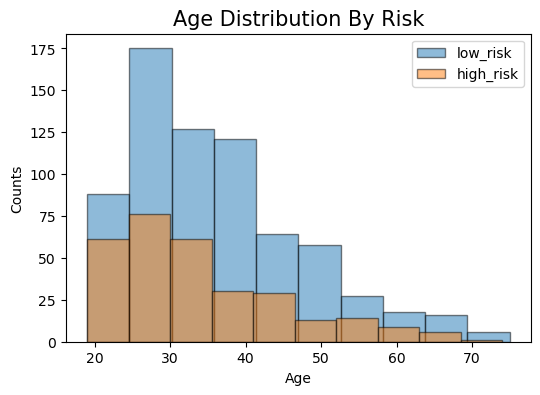

In [4]:
df_low_risk = df[df['risk_label'] == 0]
df_high_risk = df[df['risk_label'] == 1]

fix, ax = plt.subplots(figsize=(6, 4))

plt.hist(df_low_risk['age'], bins=10, edgecolor='black', color='tab:blue', label='low_risk', alpha=0.5)
plt.hist(df_high_risk['age'], bins=10, edgecolor='black', color='tab:orange', label='high_risk', alpha=0.5)
plt.title("Age Distribution By Risk", size=15)
plt.xlabel('Age')
plt.ylabel('Counts')
plt.legend();

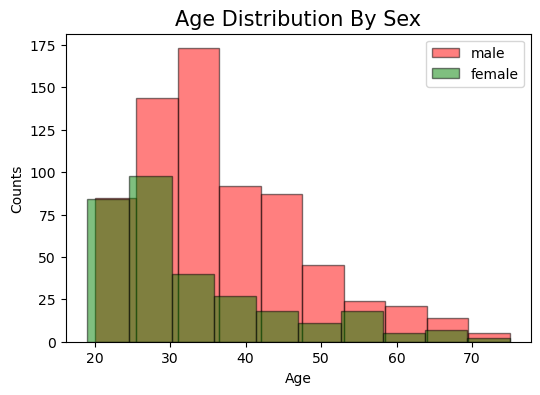

In [5]:
df_male = df[df['sex'] == 'male']
df_female = df[df['sex'] == 'female']

fix, ax = plt.subplots(figsize=(6, 4))

plt.hist(df_male['age'], bins=10, edgecolor='black', color='red', label='male', alpha=0.5)
plt.hist(df_female['age'], bins=10, edgecolor='black', color='green', label='female', alpha=0.5)
plt.title("Age Distribution By Sex", size=15)
plt.xlabel('Age')
plt.ylabel('Counts')
plt.legend();

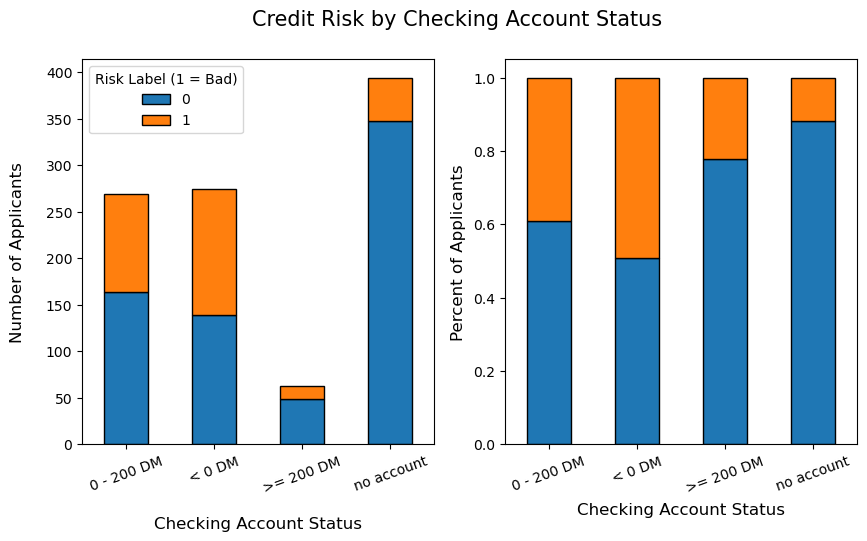

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

checking_risk = pd.crosstab(df['checking_status'], df['risk_label'])
checking_risk_pct = checking_risk.div(checking_risk.sum(axis=1), axis=0)

checking_risk.plot(kind='bar', stacked=True, edgecolor='black', ax=ax1)
ax1.set_ylabel('Number of Applicants', size=12, labelpad=15)
ax1.set_xlabel('Checking Account Status', size=12, labelpad=15)
ax1.legend(title='Risk Label (1 = Bad)')
ax1.tick_params(axis='x', rotation=20)

checking_risk_pct.plot(kind='bar', stacked=True, edgecolor='black', ax=ax2, legend=False)
ax2.set_xlabel('Checking Account Status', size=12, labelpad=5)
ax2.set_ylabel('Percent of Applicants', size=12, labelpad=5)
ax2.tick_params(axis='x', rotation=20);

fig.suptitle('Credit Risk by Checking Account Status', size=15);

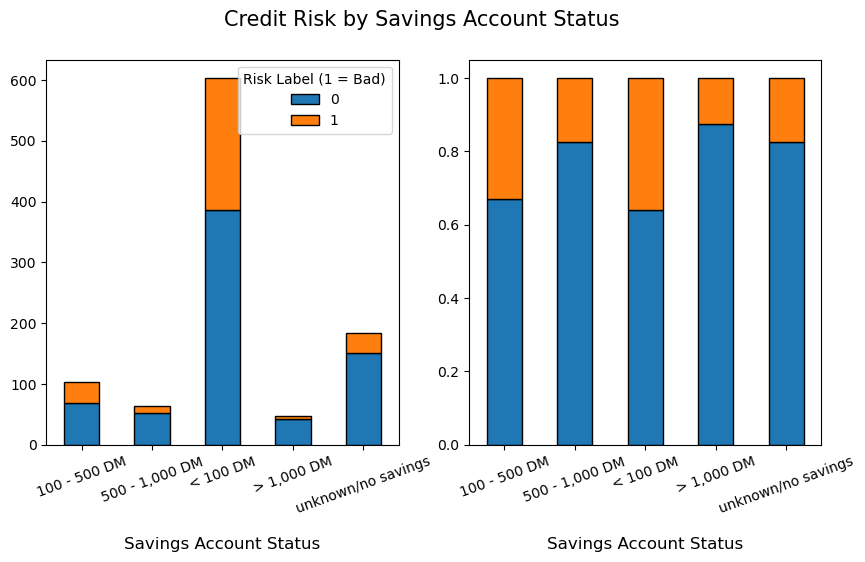

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

saving_risk = pd.crosstab(df['savings_status'], df['risk_label'])
saving_risk_pct = saving_risk.div(saving_risk.sum(axis=1), axis=0)

saving_risk.plot(kind='bar', stacked=True, edgecolor='black', ax=ax1)
ax1.set_xlabel('Savings Account Status', size=12, labelpad=15)
ax1.legend(title='Risk Label (1 = Bad)')
ax1.tick_params(axis='x', rotation=20)

saving_risk_pct.plot(kind='bar', stacked=True, edgecolor='black', ax=ax2, legend=False)
ax2.set_xlabel('Savings Account Status', size=12, labelpad=15)
ax2.tick_params(axis='x', rotation=20)

fig.suptitle('Credit Risk by Savings Account Status', size=15);

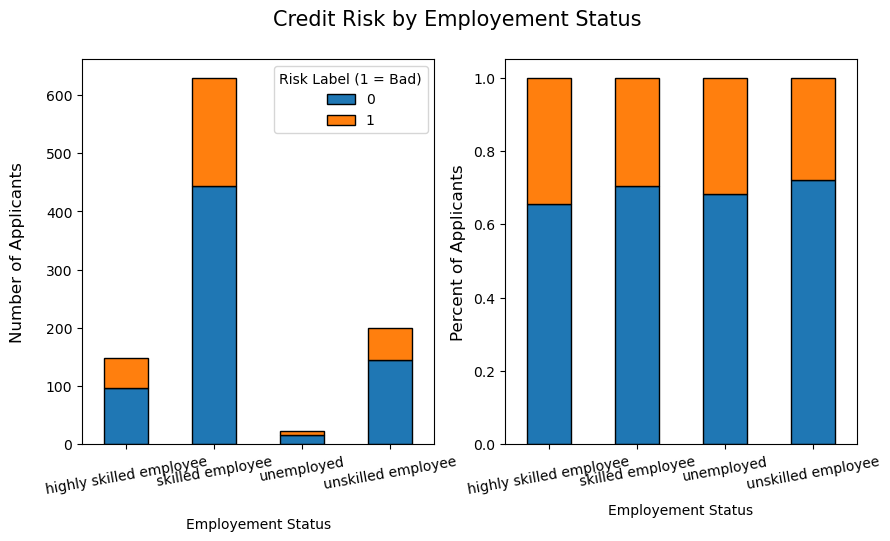

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

job_risk = pd.crosstab(df['job'], df['risk_label'])
job_risk_pct = job_risk.div(job_risk.sum(axis=1), axis=0)

job_risk.plot(kind='bar', stacked=True, edgecolor='black', ax=ax1)
ax1.tick_params(axis='x', rotation=10)
ax1.set_ylabel('Number of Applicants', size=12, labelpad=15)
ax1.set_xlabel('Employement Status', labelpad=15)
ax1.legend(title='Risk Label (1 = Bad)')


job_risk_pct.plot(kind='bar', stacked=True, edgecolor='black', ax=ax2, legend=False)
ax2.tick_params(axis='x', rotation=10)
ax2.set_xlabel('Employement Status', labelpad=5);
ax2.set_ylabel('Percent of Applicants', size=12, labelpad=5)


fig.suptitle('Credit Risk by Employement Status', size=15);

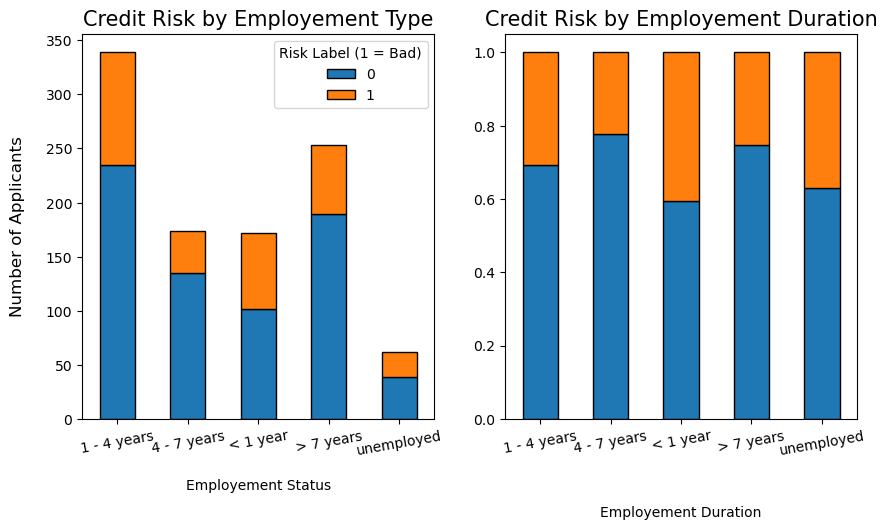

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

employ_duration_risk = pd.crosstab(df['employment_duration'], df['risk_label'])
employ_duration_risk_pct = employ_duration_risk.div(employ_duration_risk.sum(axis=1), axis=0)

employ_duration_risk.plot(kind='bar', stacked=True, edgecolor='black', ax=ax1)
ax1.tick_params(axis='x', rotation=10)
ax1.set_title('Credit Risk by Employement Type', size=15)
ax1.set_ylabel('Number of Applicants', size=12, labelpad=15)
ax1.set_xlabel('Employement Status', labelpad=15)
ax1.legend(title='Risk Label (1 = Bad)')

employ_duration_risk_pct.plot(kind='bar', stacked=True, edgecolor='black', ax=ax2, legend=False)
ax2.tick_params(axis='x', rotation=10)
ax2.set_title('Credit Risk by Employement Duration', size=15)
ax2.set_xlabel('Employement Duration', labelpad=35);

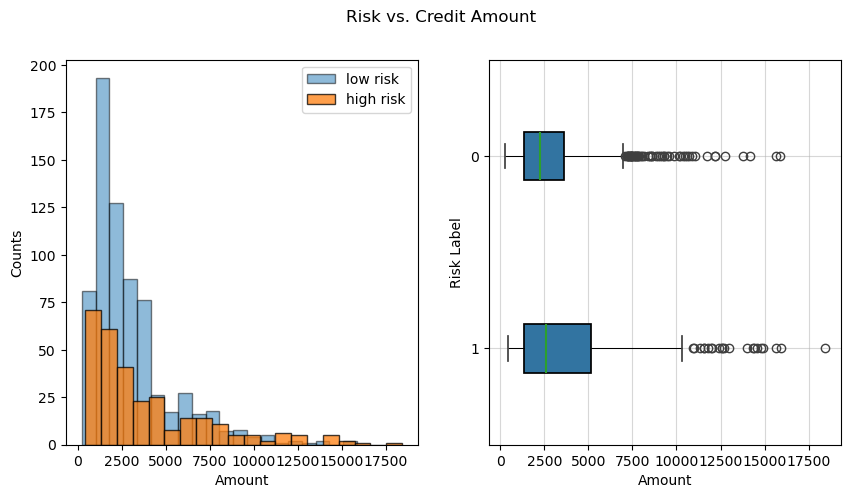

In [10]:
df_hi_risk = df[df['risk_label'] == 1]
df_lo_risk = df[df['risk_label'] == 0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.hist(df_lo_risk['amount'], bins=20, edgecolor='black', color='tab:blue', label='low risk', alpha=0.5)
ax1.hist(df_hi_risk['amount'], bins=20, edgecolor='black', color='tab:orange', label='high risk', alpha=0.75)
ax1.set_xlabel('Amount')
ax1.set_ylabel('Counts')
ax1.legend();

sns.boxplot(data=df, 
            x='amount', 
            y=df['risk_label'].astype(str), 
            color='tab:blue',
            width=0.25,
           linewidth=1.25,
           boxprops={'edgecolor': 'black'},
           medianprops={'color': 'tab:green', 'linewidth': 1.5},
           whiskerprops={'color': 'black', 'linewidth': 0.75},
           ax=ax2)
ax2.set_xlabel('Amount');
ax2.set_ylabel('Risk Label');
ax2.grid(alpha=0.5)

fig.suptitle('Risk vs. Credit Amount');

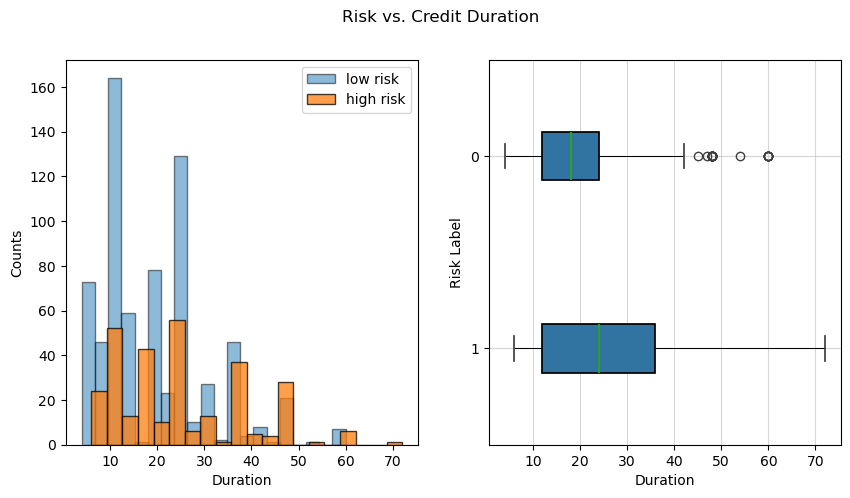

In [11]:
df_hi_risk = df[df['risk_label'] == 1]
df_lo_risk = df[df['risk_label'] == 0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.hist(df_lo_risk['duration'], bins=20, edgecolor='black', color='tab:blue', label='low risk', alpha=0.5);
ax1.hist(df_hi_risk['duration'], bins=20, edgecolor='black', color='tab:orange', label='high risk', alpha=0.75);
ax1.set_xlabel('Duration')
ax1.set_ylabel('Counts')
ax1.legend();

sns.boxplot(data=df, 
            x='duration', 
            y=df['risk_label'].astype(str), 
            color='tab:blue',
            width=0.25,
           linewidth=1.25,
           boxprops={'edgecolor': 'black'},
           medianprops={'color': 'tab:green', 'linewidth': 1.5},
           whiskerprops={'color': 'black', 'linewidth': 0.75},
           ax=ax2)
ax2.set_xlabel('Duration');
ax2.set_ylabel('Risk Label');
ax2.grid(alpha=0.5)

fig.suptitle('Risk vs. Credit Duration');

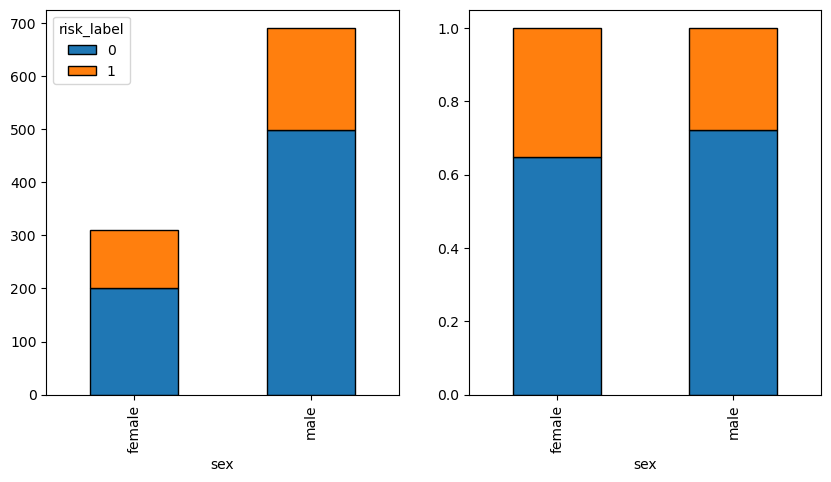

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

sex_risk = pd.crosstab(df['sex'], df['risk_label'])
sex_risk_pct = sex_risk.div(sex_risk.sum(axis=1), axis=0)

sex_risk.plot(kind='bar', stacked=True, edgecolor='black', ax=ax1)

sex_risk_pct.plot(kind='bar', stacked=True, edgecolor='black', ax=ax2, legend=False);

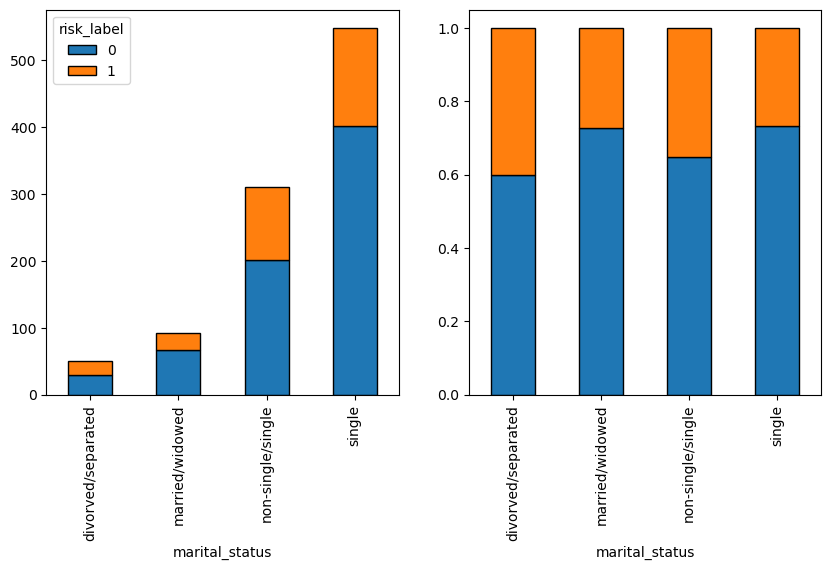

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

marital_status_risk = pd.crosstab(df['marital_status'], df['risk_label'])
marital_status_risk_pct = marital_status_risk.div(marital_status_risk.sum(axis=1), axis=0)

marital_status_risk.plot(kind='bar', stacked=True, edgecolor='black', ax=ax1)

marital_status_risk_pct.plot(kind='bar', stacked=True, edgecolor='black', ax=ax2, legend=False);

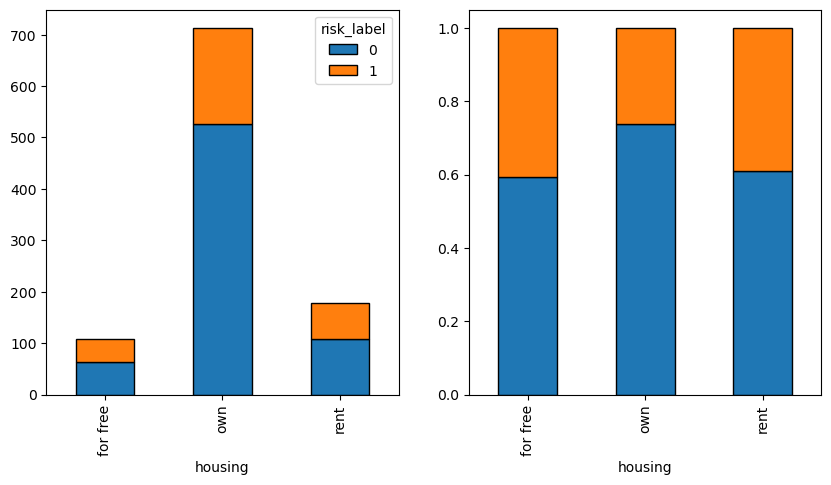

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

housing_risk = pd.crosstab(df['housing'], df['risk_label'])
housing_risk_pct = housing_risk.div(housing_risk.sum(axis=1), axis=0)

housing_risk.plot(kind='bar', stacked=True, edgecolor='black', ax=ax1)

housing_risk_pct.plot(kind='bar', stacked=True, edgecolor='black', ax=ax2, legend=False);

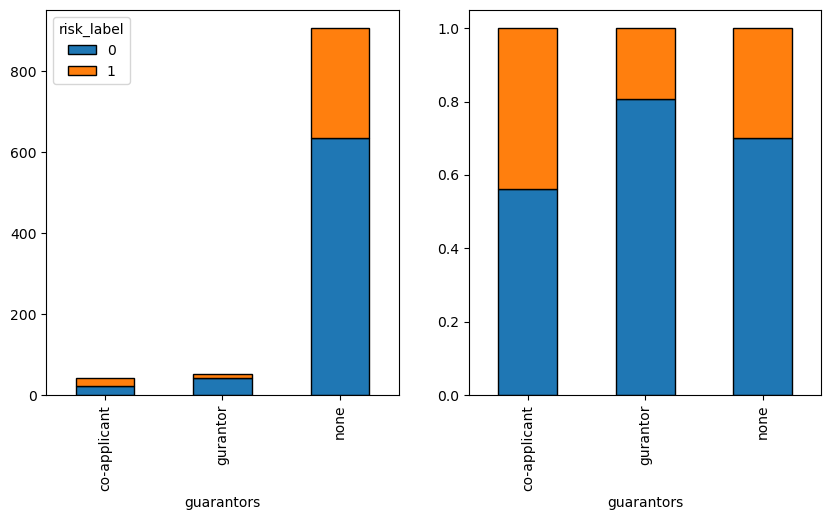

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

guarantors_risk = pd.crosstab(df['guarantors'], df['risk_label'])
guarantors_risk_pct = guarantors_risk.div(guarantors_risk.sum(axis=1), axis=0)

guarantors_risk.plot(kind='bar', stacked=True, edgecolor='black', ax=ax1)

guarantors_risk_pct.plot(kind='bar', stacked=True, edgecolor='black', ax=ax2, legend=False);

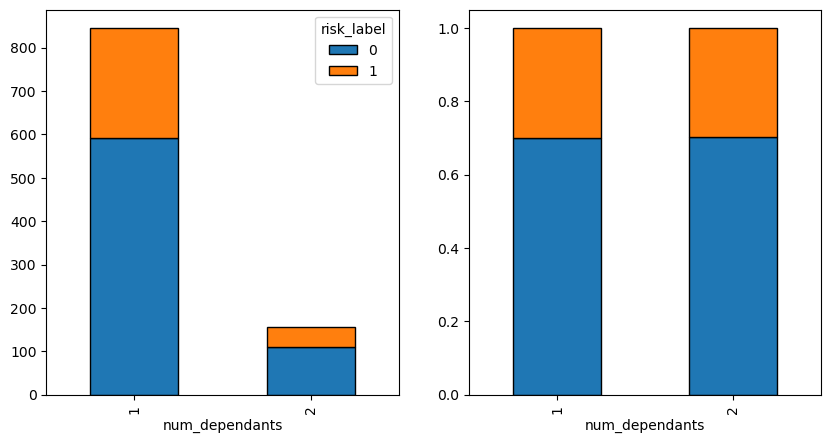

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

num_dependants_risk = pd.crosstab(df['num_dependants'], df['risk_label'])
num_dependants_risk_pct = num_dependants_risk.div(num_dependants_risk.sum(axis=1), axis=0)

num_dependants_risk.plot(kind='bar', stacked=True, edgecolor='black', ax=ax1)

num_dependants_risk_pct.plot(kind='bar', stacked=True, edgecolor='black', ax=ax2, legend=False);

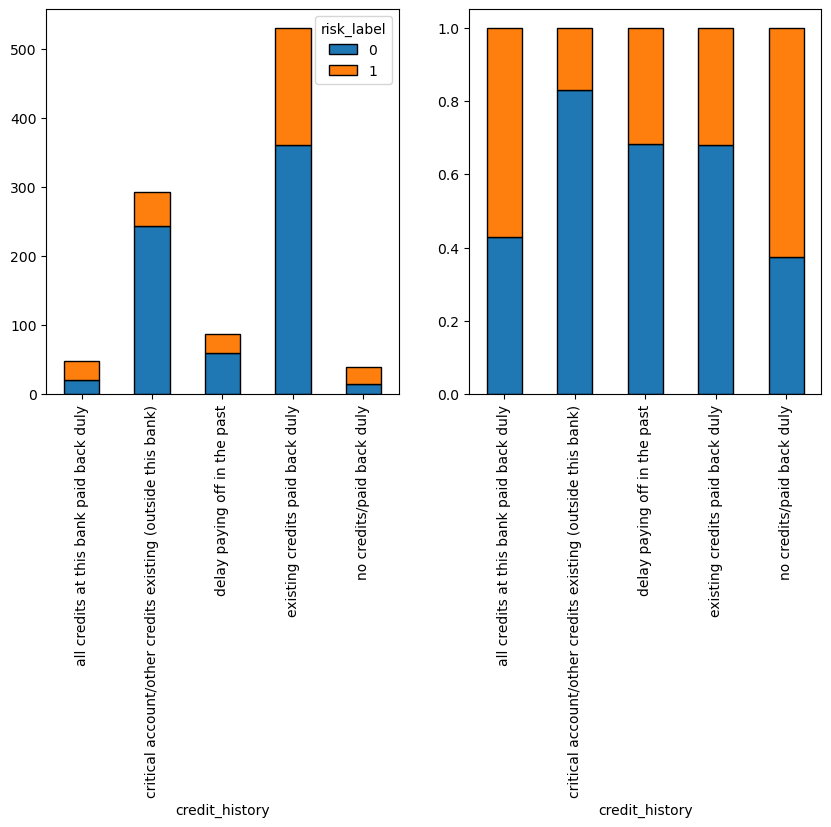

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

credit_history_risk = pd.crosstab(df['credit_history'], df['risk_label'])
credit_history_risk_pct = credit_history_risk.div(credit_history_risk.sum(axis=1), axis=0)

credit_history_risk.plot(kind='bar', stacked=True, edgecolor='black', ax=ax1)

credit_history_risk_pct.plot(kind='bar', stacked=True, edgecolor='black', ax=ax2, legend=False);

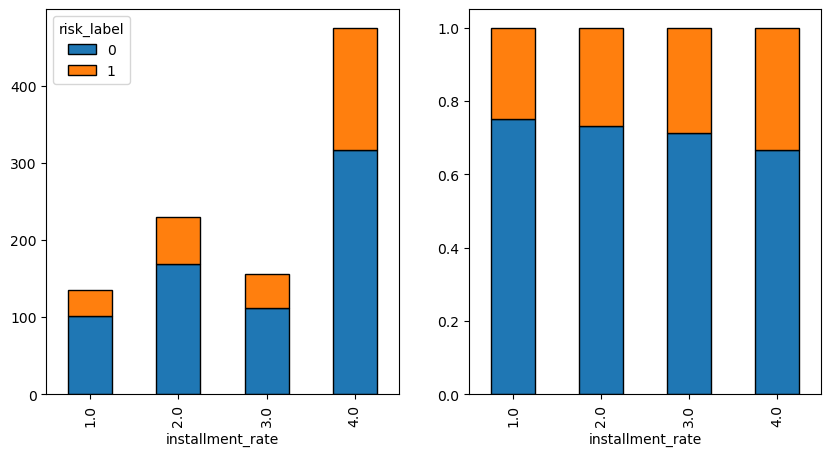

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

installment_risk = pd.crosstab(df['installment_rate'], df['risk_label'])
installment_risk_pct = installment_risk.div(installment_risk.sum(axis=1), axis=0)

installment_risk.plot(kind='bar', stacked=True, edgecolor='black', ax=ax1)

installment_risk_pct.plot(kind='bar', stacked=True, edgecolor='black', ax=ax2, legend=False);

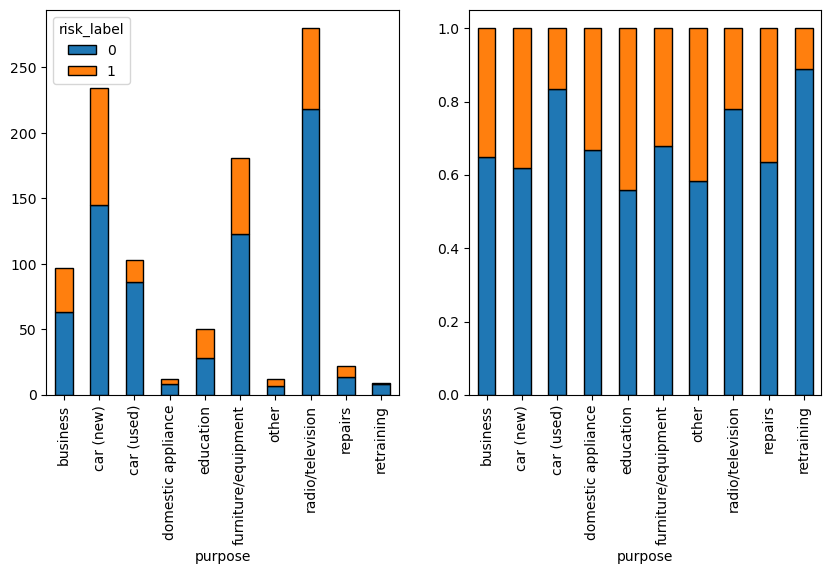

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

purpose_risk = pd.crosstab(df['purpose'], df['risk_label'])
purpose_risk_pct = purpose_risk.div(purpose_risk.sum(axis=1), axis=0)

purpose_risk.plot(kind='bar', stacked=True, edgecolor='black', ax=ax1)

purpose_risk_pct.plot(kind='bar', stacked=True, edgecolor='black', ax=ax2, legend=False);

## Check the Dataset for Multicollinearity

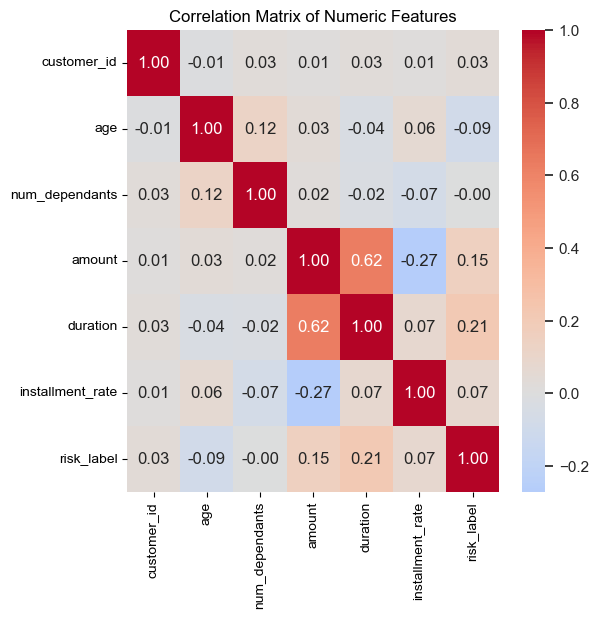

In [20]:
fig, ax = plt.subplots(figsize=(6, 6))

# Set a clean theme
sns.set_theme(style="white")

# Calculate correlations
corr = df.select_dtypes(include=['number']).corr()

# Plot the heatmap
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix of Numeric Features');

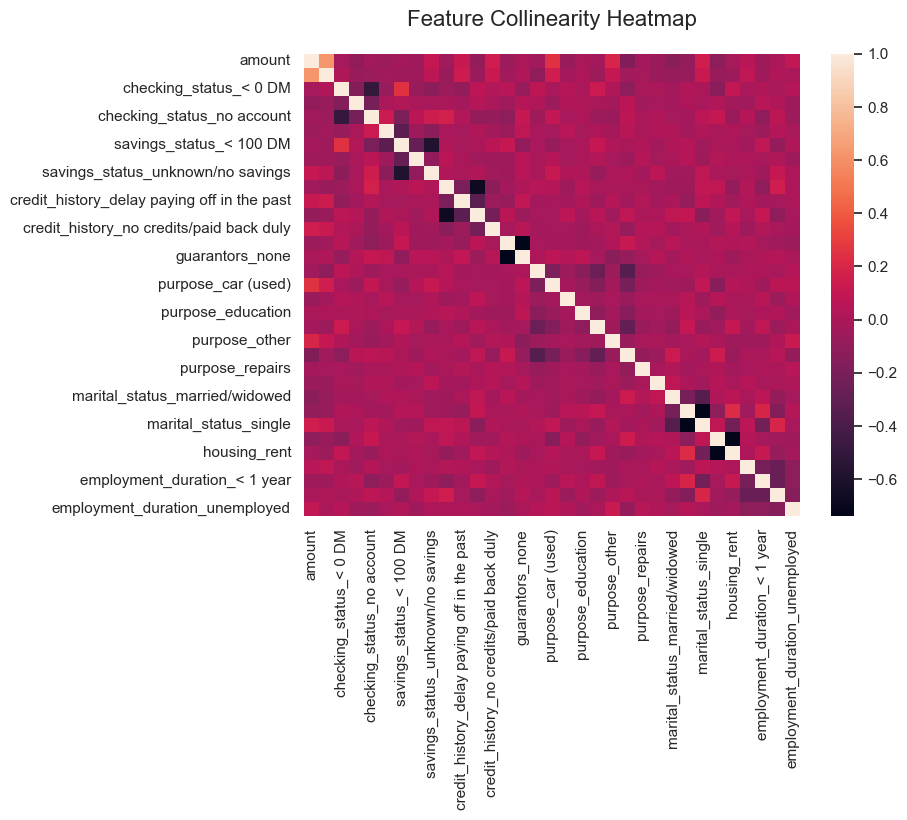

In [21]:
# Feature columns for logistic regression
feature_cols = ['checking_status', 'savings_status', 'credit_history', 'guarantors', 'purpose', 'marital_status', 'housing', 'employment_duration', 'amount', 'duration']

X = pd.get_dummies(df[feature_cols], dtype=int, drop_first=True)
X_corr = X.corr()

fig, ax = plt.subplots(figsize=(8, 6));
sns.heatmap(X_corr);
ax.set_title('Feature Collinearity Heatmap', fontsize=16, pad=20);

---

### Credit History Paradox

The initial data scan confirms a clean dataset of 1,000 entries with no missing values. The features consist of a mix of numerical financial data (amount, duration) and categorical demographic data (housing, job, marital status). Our target variable is risk_label, where '1' represents a default and '0' represents a successful repayment.

---

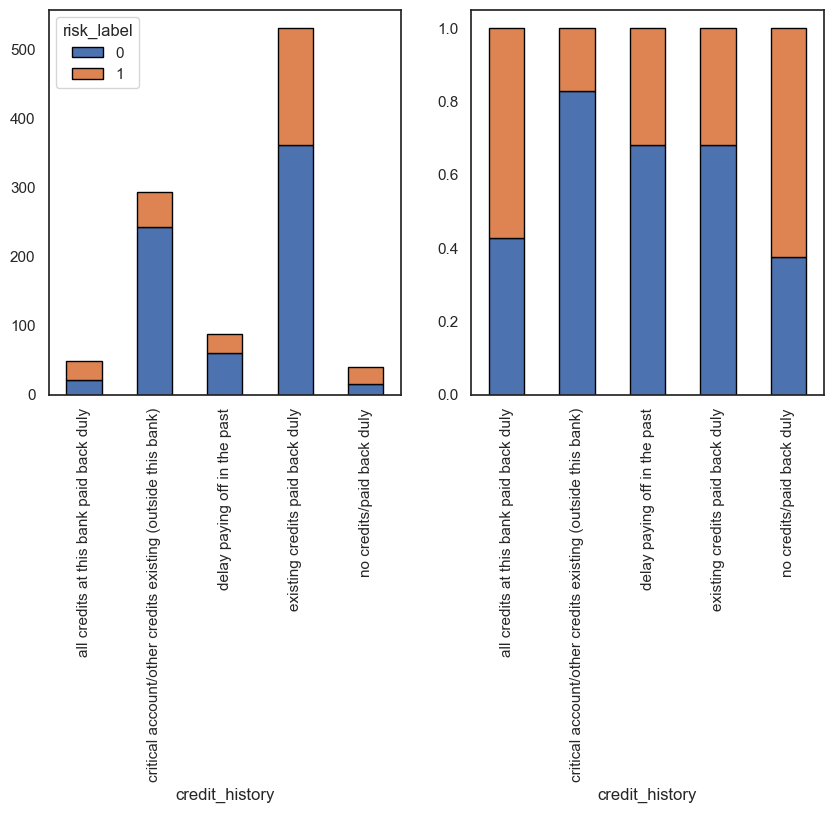

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

credit_history_risk = pd.crosstab(df['credit_history'], df['risk_label'])
credit_history_risk_pct = credit_history_risk.div(credit_history_risk.sum(axis=1), axis=0)

credit_history_risk.plot(kind='bar', stacked=True, edgecolor='black', ax=ax1)

credit_history_risk_pct.plot(kind='bar', stacked=True, edgecolor='black', ax=ax2, legend=False);

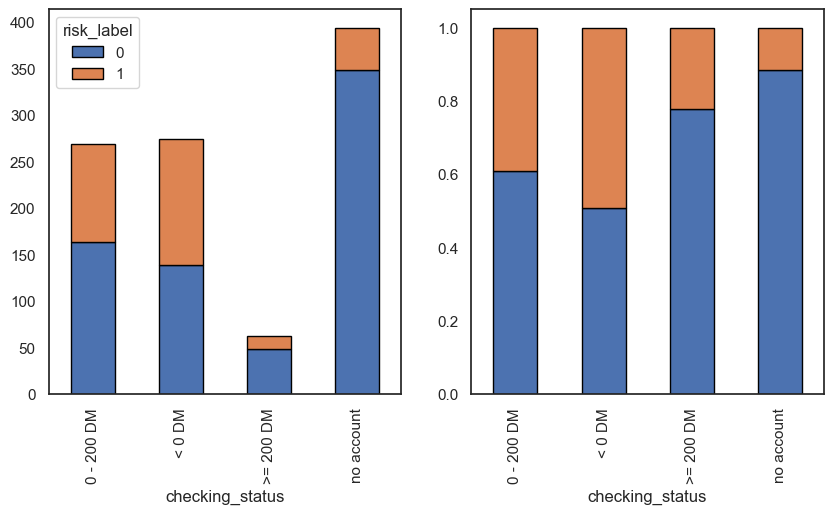

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

credit_history_risk = pd.crosstab(df['checking_status'], df['risk_label'])
credit_history_risk_pct = credit_history_risk.div(credit_history_risk.sum(axis=1), axis=0)

credit_history_risk.plot(kind='bar', stacked=True, edgecolor='black', ax=ax1)

credit_history_risk_pct.plot(kind='bar', stacked=True, edgecolor='black', ax=ax2, legend=False);

---

## EDA Conclusion & Modeling Roadmap

The EDA revealed some key components that will be necessary for our analysis:
- Key Predictors: checking_status and duration show the strongest initial correlation with risk levels.
- Data Strategy: Categorical variables like purpose and credit_history will require encoding. Due to the high number of 'purpose' categories, we may group lower-frequency categories to reduce noise.
- Model Goal: Given the financial cost of a missed default, the modeling phase will focus on maximizing Recall (Sensitivity) to capture at least 80% of high-risk cases.

---